# <h1><center> **Universidad Nacional Autonoma de México.** </center></h1>
# <h3><center> **Facultad de Estudios Superiores Acatlán.** </center></h3>
# <h4><center> **Tecnicas Estadisticas y Mineria de Datos** </center></h4>
# <h3><center>*Modulo IV*</center></h3>
---

# <center> *Proyecto Final* </center>

---
**Profesor:** JAVIER ROSAS HERNÁNDEZ \\

***Grupo - 35***                $~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~$
***30 de Junio del 2025***

Antes de comenzar hay que establecer algunas paqueterias necesarios para realizar cada uno de los incisos y de paso el exporta la informacion para su previa manipulacion breve.

In [245]:
import numpy as np      # Manipulacion de estructuras matematicas
import pandas as pd     # Manipulacion de base de datos en tablas
import seaborn as sns   # Creacion de graficas estadisticas
import matplotlib.pyplot as plt   # Creacion de las graficas descriptivas en general.

In [246]:
# ===================== Cargamos los datos ====================== #
adicc = pd.read_csv('Students Social Media Addiction.csv')

# $\color{blue}{\text{Transformacion e Limpieza de Datos}}$

Veamos algunas caracteristicas que tiene la base de datos y realizamos algunos cambios necesarios para que sea util en los modelos que deseamos aplicar...

In [247]:
# ===================== La Columnas "Students_ID" sera nuestro indexe de la base ====================== #
adicc = adicc.set_index('Student_ID')
adicc.head(10)

,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
Student_ID,,,,,,,,,,,,
1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
6,19,Female,Undergraduate,Australia,7.2,Instagram,Yes,4.5,4,Complicated,5,9
7,23,Male,Graduate,Germany,1.5,LinkedIn,No,8.0,9,Single,0,2
8,20,Female,Undergraduate,Brazil,5.8,Snapchat,Yes,6.0,6,In Relationship,2,8
9,18,Male,High School,Japan,4.0,TikTok,No,6.5,7,Single,1,5


In [248]:
# ===================== Veamos el tamano de la base de datos ====================== #
print(f"Contemplamos un total de {adicc.shape[0]} registros y {adicc.shape[1]} V.A.s")

Contemplamos un total de 705 registros y 12 V.A.s


De la visualizacion anterior; podemos ver algun que hay algunas columnas tiene ciertos tipos de valores y caracteristicas...

In [249]:
# ===================== Veamos la informacion de los datos ====================== #
adicc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 705 entries, 1 to 705
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           705 non-null    int64  
 1   Gender                        705 non-null    object 
 2   Academic_Level                705 non-null    object 
 3   Country                       705 non-null    object 
 4   Avg_Daily_Usage_Hours         705 non-null    float64
 5   Most_Used_Platform            705 non-null    object 
 6   Affects_Academic_Performance  705 non-null    object 
 7   Sleep_Hours_Per_Night         705 non-null    float64
 8   Mental_Health_Score           705 non-null    int64  
 9   Relationship_Status           705 non-null    object 
 10  Conflicts_Over_Social_Media   705 non-null    int64  
 11  Addicted_Score                705 non-null    int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 71.6+ KB


Algunas observacion sobre este informe es los siguiente:

*   Tanto: **Sleep_Hours_Per_Night** e **Avg_Daily_Usage_Hours** son V.A.s continua *(cuantitativa)*

*   Tanto: **Age**, **Mental_Health_Score**, **Conflicts_Over_Social_Media** y **Addicted_Score** Son V.A.s discretas *(Cualitativas)*

*   El resto de las V.A.s sera datos sera discretas pero sin valores numericos; de la forma en que solo son caracteres que representa algun valor nominal o ordinal...

Esto nos da incapie a que las V.A.s anteriores las cambiemos a un formato numerico y mas ligero para nuestro modelos...

In [250]:
# ===================== Comvertimos algunas V.A.s en Dummys ====================== #

# Para Gender
adicc['Gender'] = adicc['Gender'].replace({'Female': 0, 'Male': 1})

# Para Academic_Level
adicc['Academic_Level'] = adicc['Academic_Level'].replace({'High School': 1, 'Graduate': 2, 'Undergraduate': 3})

# Para Relationship_Status
adicc['Relationship_Status'] = adicc['Relationship_Status'].replace({'Complicated': 1, 'Single': 2, 'In Relationship': 3})

# Para Affects_Academic_Performance
adicc['Affects_Academic_Performance'] = adicc['Affects_Academic_Performance'].replace({'No': 0, 'Yes': 1})

adicc.head(10)

/tmp/ipython-input-250-307244015.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adicc['Gender'] = adicc['Gender'].replace({'Female': 0, 'Male': 1})
/tmp/ipython-input-250-307244015.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adicc['Academic_Level'] = adicc['Academic_Level'].replace({'High School': 1, 'Graduate': 2, 'Undergraduate': 3})
/tmp/ipython-input-250-307244015.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly ca

,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
Student_ID,,,,,,,,,,,,
1,19,0,3,Bangladesh,5.2,Instagram,1,6.5,6,3,3,8
2,22,1,2,India,2.1,Twitter,0,7.5,8,2,0,3
3,20,0,3,USA,6.0,TikTok,1,5.0,5,1,4,9
4,18,1,1,UK,3.0,YouTube,0,7.0,7,2,1,4
5,21,1,2,Canada,4.5,Facebook,1,6.0,6,3,2,7
6,19,0,3,Australia,7.2,Instagram,1,4.5,4,1,5,9
7,23,1,2,Germany,1.5,LinkedIn,0,8.0,9,2,0,2
8,20,0,3,Brazil,5.8,Snapchat,1,6.0,6,3,2,8
9,18,1,1,Japan,4.0,TikTok,0,6.5,7,2,1,5


In [251]:
# ===================== Checamos denuevo los detalles de la base de datos ====================== #
adicc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 705 entries, 1 to 705
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           705 non-null    int64  
 1   Gender                        705 non-null    int64  
 2   Academic_Level                705 non-null    int64  
 3   Country                       705 non-null    object 
 4   Avg_Daily_Usage_Hours         705 non-null    float64
 5   Most_Used_Platform            705 non-null    object 
 6   Affects_Academic_Performance  705 non-null    int64  
 7   Sleep_Hours_Per_Night         705 non-null    float64
 8   Mental_Health_Score           705 non-null    int64  
 9   Relationship_Status           705 non-null    int64  
 10  Conflicts_Over_Social_Media   705 non-null    int64  
 11  Addicted_Score                705 non-null    int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 71.6+ KB


Dejando a un lado lo que son las columnas: **Country** y **Most_Used_Platform** de la base de datos.

La razon de  esta desiciones es porque la información que contienen no aporta valor significativo al análisis. Esto se debe a que su utilidad es principalmente estructural o administrativa dentro de un esquema tipo **data warehouse**, más que analítica.

Pero esto no quita el hecho de que podemos ver graficas buenas con esta informacion...

In [252]:
# ===================== Quitamos columnas ====================== #
adicc_1 = adicc.drop(['Country', 'Most_Used_Platform'], axis = 1)
adicc_1.head(10)

,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
Student_ID,,,,,,,,,,
1,19,0,3,5.2,1,6.5,6,3,3,8
2,22,1,2,2.1,0,7.5,8,2,0,3
3,20,0,3,6.0,1,5.0,5,1,4,9
4,18,1,1,3.0,0,7.0,7,2,1,4
5,21,1,2,4.5,1,6.0,6,3,2,7
6,19,0,3,7.2,1,4.5,4,1,5,9
7,23,1,2,1.5,0,8.0,9,2,0,2
8,20,0,3,5.8,1,6.0,6,3,2,8
9,18,1,1,4.0,0,6.5,7,2,1,5


Revisemos el rango de valores que estipularon *(y los que hemos transformado)* en el diccionario.

In [253]:
# ===================== Rango de las V.A.s con rangos pequenos ====================== #
for i in adicc_1.columns:
  if i in ['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night']:
    continue
  else:
    print(f"Los valores unicos de {i}: {adicc_1[i].unique()}")
    print("")

Los valores unicos de Age: [19 22 20 18 21 23 24]

Los valores unicos de Gender: [0 1]

Los valores unicos de Academic_Level: [3 2 1]

Los valores unicos de Affects_Academic_Performance: [1 0]

Los valores unicos de Mental_Health_Score: [6 8 5 7 4 9]

Los valores unicos de Relationship_Status: [3 2 1]

Los valores unicos de Conflicts_Over_Social_Media: [3 0 4 1 2 5]

Los valores unicos de Addicted_Score: [8 3 9 4 7 2 5 6]



In [254]:
# ===================== Rango de las V.A.s con rangos grandes ====================== #
for i in adicc_1.columns:
  if i in ['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night']:
    print(f"Los valores unicos de {i}: {adicc_1[i].unique()}")
    print("")
  else:
    continue

Los valores unicos de Avg_Daily_Usage_Hours: [5.2 2.1 6.  3.  4.5 7.2 1.5 5.8 4.  3.3 4.8 5.5 2.8 6.5 3.7 4.2 2.  5.
 3.5 4.7 5.3 2.5 4.9 5.7 3.2 6.1 3.8 4.4 2.2 5.9 3.6 5.4 2.6 5.6 3.1 6.2
 3.9 2.3 4.6 2.7 6.3 2.4 2.9 5.1 4.3 4.1 3.4 6.4 7.  6.8 6.9 6.7 6.6 7.1
 7.3 7.4 7.5 7.6 7.7 7.8 7.9 8.  8.1 8.2 8.3 8.4 8.5]

Los valores unicos de Sleep_Hours_Per_Night: [6.5 7.5 5.  7.  6.  4.5 8.  6.2 5.8 7.2 5.5 6.8 7.8 5.7 6.7 5.9 7.3 5.4
 6.9 5.2 6.6 7.4 5.3 5.1 7.1 5.6 6.4 6.3 6.1 7.6 7.7 7.9 8.1 8.2 8.3 4.9
 8.4 4.8 8.5 4.7 8.6 4.6 4.4 8.7 4.3 8.8 4.2 8.9 4.1 9.  9.1 9.2 9.3 9.4
 4.  9.5 3.9 9.6 3.8]



Podemos afirmar que los datos estan dentro de los rangos que estipula la investigacion.

Pasando a la parte de la limpieza de los datos; Los investigadores nos dejaron notas de la limpieza y consideracion que utilizaron, pero no esta de mas comprobarlo antes de utilizarlos.

Comprobemos que si hay datos duplicados e valores nulos en los datos...

In [255]:
# Para los valores duplicados
adicc_1[adicc.duplicated()]

,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
Student_ID,,,,,,,,,,
274,21,1,2,5.4,1,6.7,5,2,3,7


In [256]:
# Veamos si esta los registros con el indice anterior
adicc_1.iloc[273]

,274
Age,21.0
Gender,1.0
Academic_Level,2.0
Avg_Daily_Usage_Hours,5.4
Affects_Academic_Performance,1.0
Sleep_Hours_Per_Night,6.7
Mental_Health_Score,5.0
Relationship_Status,2.0
Conflicts_Over_Social_Media,3.0
Addicted_Score,7.0


Al parece es el registro es unico; pero la razon por la que parece sera porque hay una fila que contiene los mismo datos que la que nos esta indicando.

Los detalles que nos deja los investigadores que desarrollaron esta base de datos, existe la posibilidad de que *(al ser un resumen de una encuesta)* 2 personas tenga la misma informacion en los registros de las base de datos; pero, que las respuestas de la encuesta sean muy distintas...

Pero al no estar seguros de la afirmacion anterior, sera mejor eliminar este registro *(para una mejor variedad de datos que alimente mejor a nuestros modelos)*.

In [257]:
# Eliminamos el registro con el indice 274
adicc_1 = adicc_1.drop(273)

In [258]:
# para los valores nulos
Vacios = pd.DataFrame(adicc_1.isnull().sum(), columns = ['Valores_Nulls'])
Vacios

,Valores_Nulls
Age,0
Gender,0
Academic_Level,0
Avg_Daily_Usage_Hours,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,0
Mental_Health_Score,0
Relationship_Status,0
Conflicts_Over_Social_Media,0
Addicted_Score,0


In [259]:
# ===================== Veamos devuelta el tamano de la base de datos ====================== #
print(f"Contemplamos un total de {adicc_1.shape[0]} registros y {adicc_1.shape[1]} V.A.s")

Contemplamos un total de 704 registros y 10 V.A.s


# $\color{blue}{\text{Analisis de Datos}}$

## $\color{green}{\text{Graficas}}$

Para este apartada se crearan algunas graficas e ilustraciones que nos apoyaran mucha en el comportamiento e entendimiento de la informacion a la que deseamos modelar...

/tmp/ipython-input-260-2264728194.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(adicc_1['Avg_Daily_Usage_Hours'], ax = axes[0], color = 'skyblue')
/tmp/ipython-input-260-2264728194.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(adicc_1['Sleep_Hours_Per_Night'], ax = axes[1], color = 

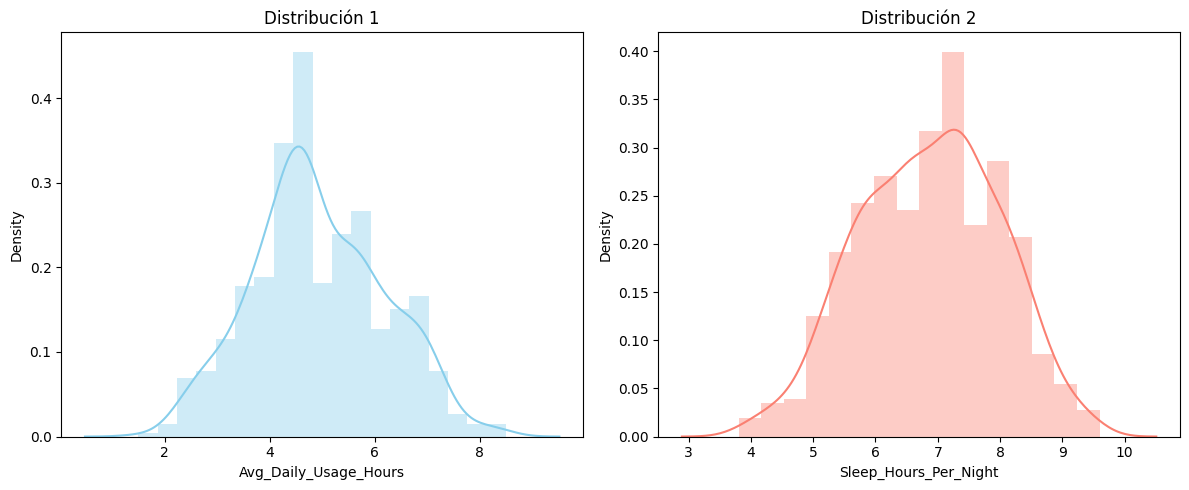

In [260]:
# ===================== distribucion de probabilidad de 'Avg_Daily_Usage_Hours' y 'Sleep_Hours_Per_Night' ====================== #

# establecemos el lienzo en 2 partes
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

# Distribución 1
sns.distplot(adicc_1['Avg_Daily_Usage_Hours'], ax = axes[0], color = 'skyblue')
axes[0].set_title("Distribución 1")

# Distribución 2
sns.distplot(adicc_1['Sleep_Hours_Per_Night'], ax = axes[1], color = 'salmon')
axes[1].set_title("Distribución 2")

plt.tight_layout()
plt.show()

Podemos observar que estas V.A.s tiene un comportamiento de una distribucion normal *(algo que nos favorece de escoger estas variable para el modelo de regresion lineal)*

Veamos si hay algun dato atipos por medio de las cajas Box por medio de estas V.A.s....

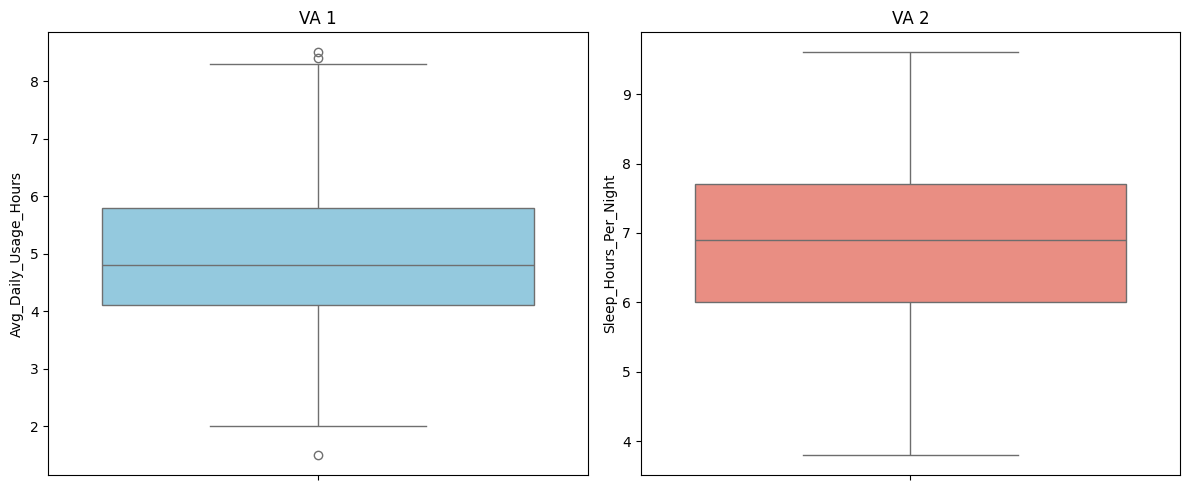

In [261]:
# ===================== Cajas Box de 'Avg_Daily_Usage_Hours' y 'Sleep_Hours_Per_Night' ====================== #

# establecemos el lienzo en 2 partes
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

# Distribución 1
sns.boxplot(adicc_1['Avg_Daily_Usage_Hours'], ax = axes[0], color = 'skyblue')
axes[0].set_title("VA 1")

# Distribución 2
sns.boxplot(adicc_1['Sleep_Hours_Per_Night'], ax = axes[1], color = 'salmon')
axes[1].set_title("VA 2")

plt.tight_layout()
plt.show()

Podemos detectar que hay una presencia de valores atipicos que puedan alterar la informacion que deseamos clasificar e predecir. Pero no es suficientemente para descartar esto registro...

Veamos como queda la grafica de dispersion para tener mejor claridad; pero las variables clasificatorias no nos ayuda en ese aspecto solo las anteriores V.A.s y eso de que de las V.A. objetivo **Y** no puede ser utilizada para nuestro proposito...

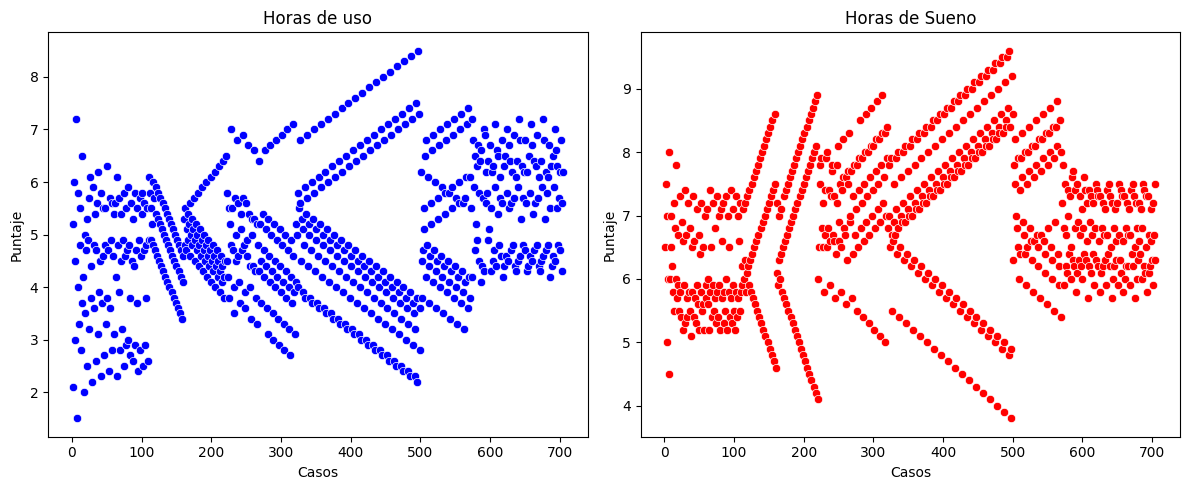

In [262]:
# ===================== Graficas de dispersion ====================== #

# establecemos el lienzo en 2 partes
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

# Distribución 1
sns.scatterplot(x = adicc_1.index, y = adicc_1['Avg_Daily_Usage_Hours'], ax = axes[0], color = 'blue')
axes[0].set_title("Horas de uso")
axes[0].set_xlabel("Casos")
axes[0].set_ylabel("Puntaje")

# Distribución 2
sns.scatterplot(x = adicc_1.index, y = adicc_1['Sleep_Hours_Per_Night'], ax = axes[1], color = 'red')
axes[1].set_title("Horas de Sueno")
axes[1].set_xlabel("Casos")
axes[1].set_ylabel("Puntaje")

plt.tight_layout()
plt.show()

Podemos ver que no hay presencia de datos atipicos, pero si hay cosas raraz.

Como lo pueden ver la forma en como se traza los puntos no es nada naturales y es posible que el resumen de las informacion de las respuesta de las encuestas no esta bien definidad que causa estos desordenes...

Veamos los conteos de los registros de las V.A.s Boleanas

/tmp/ipython-input-263-1721953645.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = adicc_1, x = 'Gender', palette = 'pastel')


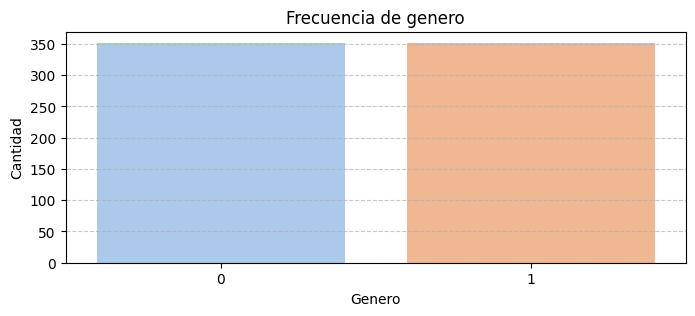

In [263]:
# ===================== Graficas de proporcion (genero) ====================== #

# establecemos el lienzo
plt.figure(figsize = (8,3))

# configuramos la grafica de barras
sns.countplot(data = adicc_1, x = 'Gender', palette = 'pastel')
plt.title('Frecuencia de genero')
plt.xlabel('Genero')
plt.ylabel('Cantidad')

# Configuramos el lienzo
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.show()

/tmp/ipython-input-264-2346198371.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = adicc_1, x = 'Affects_Academic_Performance', palette = 'pastel')


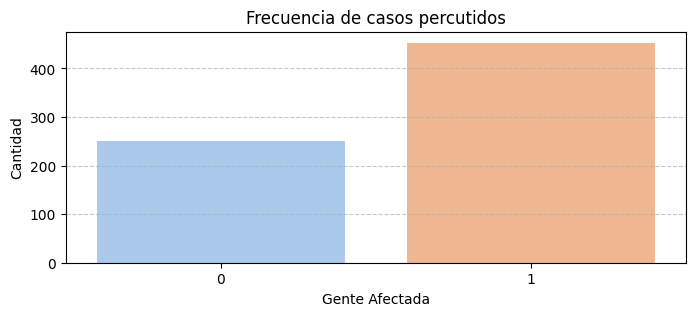

In [264]:
# ===================== Graficas de proporcion (Afectacion educativa) ====================== #

# establecemos el lienzo
plt.figure(figsize = (8,3))

# configuramos la grafica de barras
sns.countplot(data = adicc_1, x = 'Affects_Academic_Performance', palette = 'pastel')
plt.title('Frecuencia de casos percutidos')
plt.xlabel('Gente Afectada')
plt.ylabel('Cantidad')

# Configuramos el lienzo
plt.grid(axis='y', linestyle='--', alpha = 0.7)
plt.show()

In [265]:
# Calculamos las proporcion de las filas que tiene afectacion educativas
proporcion = adicc_1['Affects_Academic_Performance'].value_counts(normalize = True)
print(proporcion)

Affects_Academic_Performance
1    0.643466
0    0.356534
Name: proportion, dtype: float64


Veamos otro ejemplo del conteo.....

/tmp/ipython-input-266-394558400.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = adicc_1, x = 'Relationship_Status', palette = 'pastel')


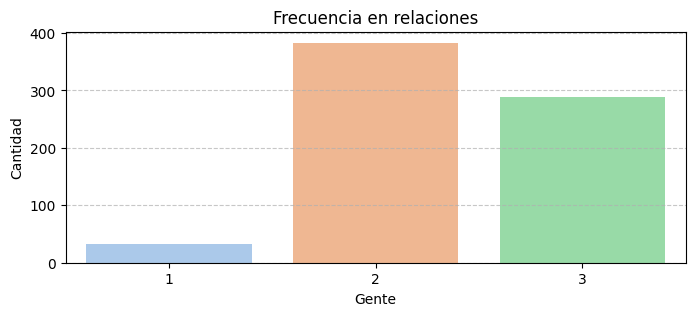

In [266]:
# ===================== Graficas de proporcion (Conteo de relaciones) ====================== #

# establecemos el lienzo
plt.figure(figsize = (8,3))

# configuramos la grafica de barras
sns.countplot(data = adicc_1, x = 'Relationship_Status', palette = 'pastel')
plt.title('Frecuencia en relaciones')
plt.xlabel('Gente')
plt.ylabel('Cantidad')

# Configuramos el lienzo
plt.grid(axis='y', linestyle='--', alpha = 0.7)
plt.show()

In [267]:
# Calculamos las proporcion de las filas que tiene afectacion educativas
proporcion = adicc_1['Relationship_Status'].value_counts(normalize = True)
print(proporcion)

Relationship_Status
2    0.544034
3    0.410511
1    0.045455
Name: proportion, dtype: float64


Por ultimo, veamos otro ejemplos de histogramas de las demas V.A.s

/tmp/ipython-input-268-1238004758.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data = adicc_1, x = 'Age', palette = 'pastel')


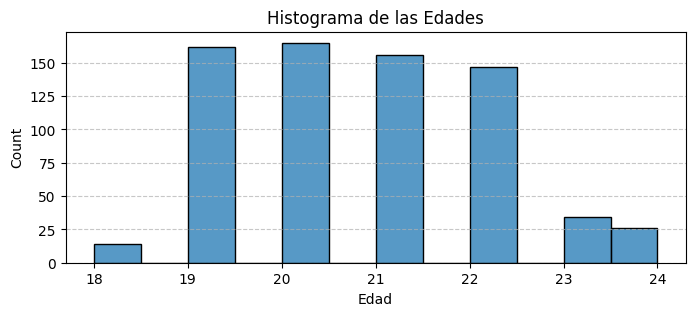

In [268]:
# ===================== Histograma (Conteo de relaciones) ====================== #

# establecemos el lienzo
plt.figure(figsize = (8,3))

# configuramos la grafica de barras
sns.histplot(data = adicc_1, x = 'Age', palette = 'pastel')
plt.title('Histograma de las Edades')
plt.xlabel('Edad')

# Configuramos el lienzo
plt.grid(axis='y', linestyle='--', alpha = 0.7)
plt.show()

/tmp/ipython-input-269-3621475637.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data = adicc_1, x = 'Conflicts_Over_Social_Media', palette = 'pastel')


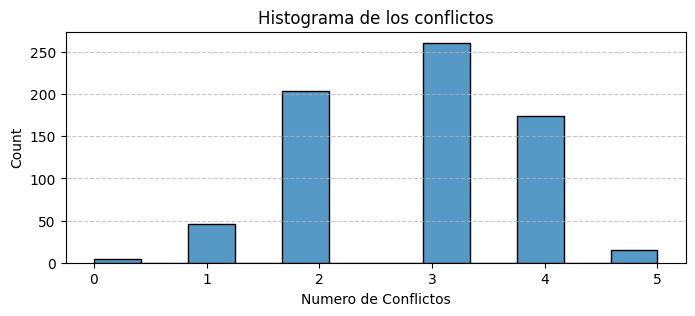

In [269]:
# ===================== Histograma (Conteo de conflictos) ====================== #

# establecemos el lienzo
plt.figure(figsize = (8,3))

# configuramos la grafica de barras
sns.histplot(data = adicc_1, x = 'Conflicts_Over_Social_Media', palette = 'pastel')
plt.title('Histograma de los conflictos')
plt.xlabel('Numero de Conflictos')

# Configuramos el lienzo
plt.grid(axis='y', linestyle='--', alpha = 0.7)
plt.show()

Veamos de que parte del mundo han participado mas las personas y las plataformas mas usadas...

/tmp/ipython-input-270-3240910257.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = adicc, x = 'Country', palette = 'pastel')


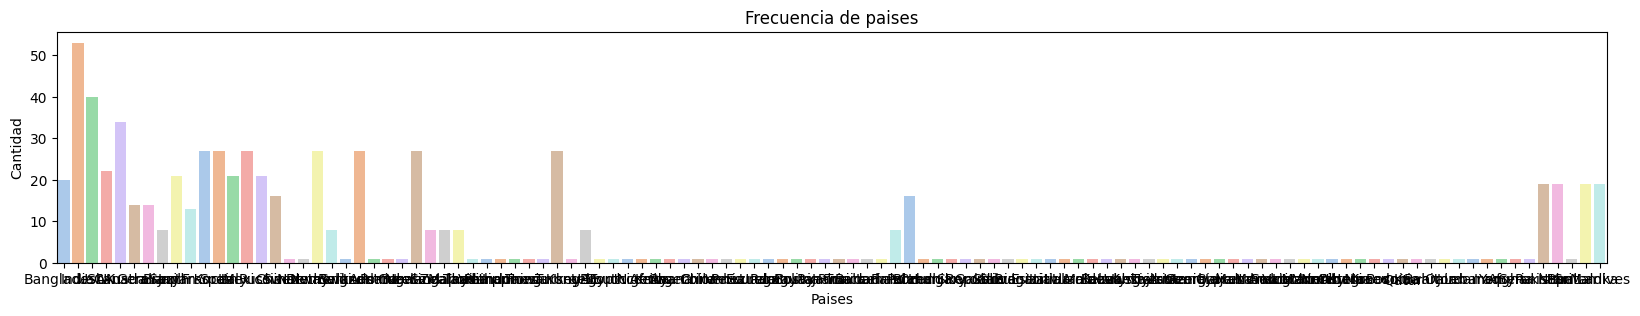

In [270]:
# ================ De donde viene los registros una grafica de barras ===========================

# Configuramos el tamaño del lienzo
plt.figure(figsize = (20,3))

sns.countplot(data = adicc, x = 'Country', palette = 'pastel')
plt.title('Frecuencia de paises')
plt.xlabel('Paises')
plt.ylabel('Cantidad')

plt.show()

Como no podemos verlo de forma visual; lo haremos por una lista de valores...

In [271]:
# Veamos las donde proviene la mayoria de los registros...
conteo = pd.DataFrame(adicc['Country'].value_counts())
conteo

,count
Country,
India,53
USA,40
Canada,34
France,27
Mexico,27
...,...
Oman,1
Afghanistan,1
Syria,1


In [272]:
# Veamos por parte las el conteo
conteo.head(15)

,count
Country,
India,53
USA,40
Canada,34
France,27
Mexico,27
Spain,27
Turkey,27
Ireland,27
Denmark,27


In [273]:
conteo.iloc[15:30,:]

,count
Country,
Maldives,19
Sri Lanka,19
Nepal,19
Pakistan,19
China,16
Poland,16
Germany,14
Australia,14
South Korea,13


In [274]:
conteo.iloc[30:45,:]

,count
Country,
Finland,8
Austria,1
Thailand,1
Philippines,1
Taiwan,1
Indonesia,1
Hong Kong,1
Israel,1
Egypt,1


In [275]:
conteo.iloc[45:60,:]

,count
Country,
Norway,1
Chile,1
Argentina,1
Ghana,1
Kenya,1
Nigeria,1
South Africa,1
Colombia,1
Peru,1


In [276]:
conteo.iloc[60:75,:]

,count
Country,
Venezuela,1
Ecuador,1
Hungary,1
Czech Republic,1
Slovakia,1
Croatia,1
Serbia,1
Slovenia,1
Bulgaria,1


In [277]:
conteo.iloc[75:90,:].transpose()

Country,Trinidad,Iceland,Romania,Kyrgyzstan,Uzbekistan,Kazakhstan,Belarus,Tajikistan,Armenia,Georgia,Azerbaijan,Andorra,San Marino,Vatican City,Liechtenstein
count,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [278]:
conteo.iloc[90:110,:].transpose()

Country,Cyprus,Malta,Luxembourg,Monaco,Kosovo,North Macedonia,Albania,Montenegro,Bosnia,Qatar,Kuwait,Bahrain,Iraq,Lebanon,Jordan,Oman,Afghanistan,Syria,Yemen,Bhutan
count,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [279]:
# Veamos cual es la preferencias de las plataforma...
plataforma = pd.DataFrame(adicc['Most_Used_Platform'].value_counts()).transpose()
plataforma

Most_Used_Platform,Instagram,TikTok,Facebook,WhatsApp,Twitter,LinkedIn,WeChat,Snapchat,VKontakte,LINE,KakaoTalk,YouTube
count,249,154,123,54,30,21,15,13,12,12,12,10


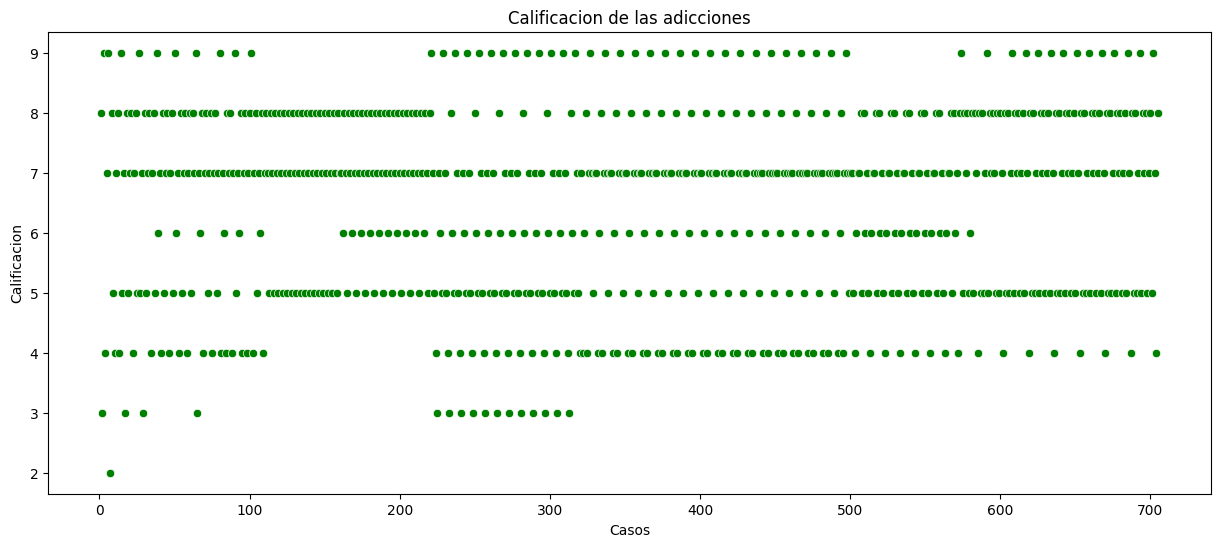

In [280]:
# En cuanto a la V.A.s objetivo la podemos ver distribuidas de las forma siguiente:

# ===================== Graficas de dispersion ====================== #

# Configuramos el tamaño del lienzo
plt.figure(figsize = (15,6))

sns.scatterplot(x = adicc.index, y = adicc['Addicted_Score'], color = 'green')
plt.title('Calificacion de las adicciones')
plt.xlabel('Casos')
plt.ylabel('Calificacion')

plt.show()

## $\color{green}{\text{Estadisticas Descriptivas}}$

Para este apartada se veran algunos parametros que nos ofrece esta poblacion que marcan mucho una poblacion...

Para las variables que no son categoricas...

In [281]:
# Variables que descartamos por ser columnas categoricas
Nop = ['Gender', 'Academic_Level', 'Affects_Academic_Performance', 'Mental_Health_Score', 'Relationship_Status', 'Addicted_Score']

# Calculamos los valores estadisticos
Est_Matriz = adicc_1.drop(Nop, axis = 1).describe().round(3)

# Quitamos las filas de conteo y las Cuartiles (por ahora)
Parte_1 = Est_Matriz.drop(['count', '25%', '50%', '75%'], axis = 0)

# Cambiamos el nombre de los indices..
Parte_1.index = ['Promedio', 'Desviacion', 'Minimo', 'Maximo']
Parte_1

,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Conflicts_Over_Social_Media
Promedio,20.662,4.921,6.867,2.852
Desviacion,1.399,1.257,1.126,0.956
Minimo,18.000,1.500,3.800,0.000
Maximo,24.000,8.500,9.600,5.000


In [282]:
# Veamos los cuartiles que nos ofrece por aparte
Parte_2 = Est_Matriz.drop(['count', 'mean', 'std', 'min', 'max'], axis = 0)

# Cambiamos el nombre de los indices..
Parte_2.index = ['Cuartil 25%', 'Mediana', 'Cuartil 75%']
Parte_2

,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Conflicts_Over_Social_Media
Cuartil 25%,19.75,4.1,6.0,2.0
Mediana,21.00,4.8,6.9,3.0
Cuartil 75%,22.00,5.8,7.7,4.0


Para las Variablres Categoricas podemos calcular la moda....

In [283]:
# Traemos la lista "Nop" para establecer la moda:
M_Est = adicc_1[Nop].mode()
M_Est

,Gender,Academic_Level,Affects_Academic_Performance,Mental_Health_Score,Relationship_Status,Addicted_Score
0,0,3.0,1.0,6.0,2.0,7.0
1,1,NaN,NaN,NaN,NaN,NaN


Y Por ultimo; como se desarrolla la relacion que tiene entre si las V.A.s

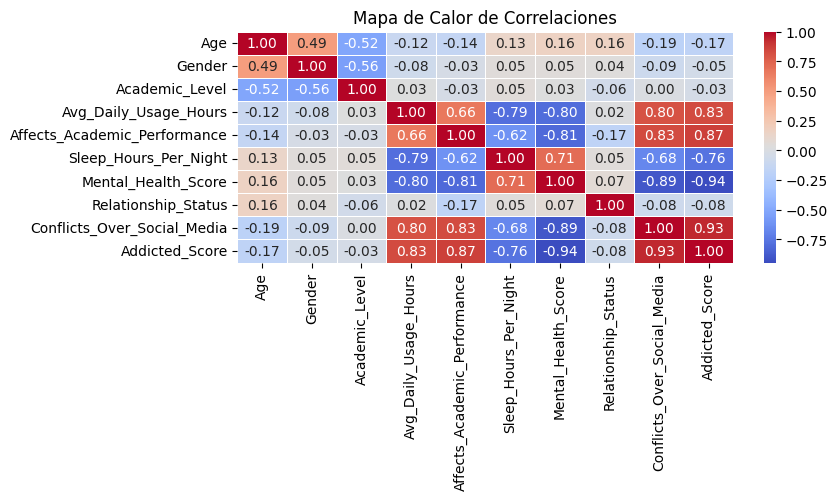

In [284]:
# ===================== Histograma (Conteo de relaciones) ====================== #
# realizamos la correlacion de pearson de la base de datos
Corr_Adic = adicc_1.corr()

# Configuramos el tamaño del lienzo
plt.figure(figsize = (8,3))

# Gráfica de calor
sns.heatmap(Corr_Adic, annot = True, cmap = 'coolwarm', fmt = ".2f", linewidths = 0.5)

# Configuramos el mapa y el lienzo
plt.title("Mapa de Calor de Correlaciones")
plt.show()


In [285]:
# Esta son las V.A.s que mas se relacion con la V.A. objetivo:
Adic_Corr = Corr_Adic.sort_values(by = 'Addicted_Score', ascending = False)
Adic_Corr['Addicted_Score']

,Addicted_Score
Addicted_Score,1.000000
Conflicts_Over_Social_Media,0.933225
Affects_Academic_Performance,0.865917
Avg_Daily_Usage_Hours,0.831670
Academic_Level,-0.033967
Gender,-0.052980
Relationship_Status,-0.075137
Age,-0.170790
Sleep_Hours_Per_Night,-0.764227
Mental_Health_Score,-0.944991


# $\color{blue}{\text{Random Forest}}$

## $\color{green}{\text{Con Y = Addicted_Score}}$

In [286]:
# ===================== Partimos el database en train y test ====================== #

#importamos la sig, funcion:
from sklearn.model_selection import train_test_split

# Designamos que variable es quien:
X = adicc_1.drop('Addicted_Score', axis = 1)    # X sera las V.A.s independientes
Y = adicc_1['Addicted_Score']                   # Y sera las V.A. dependiente

# Vamos a entrenar el modelo con el 70% y con el 30% sera las parte del test
x_train, x_test, y_train, y_test = train_test_split(X, Y, train_size = .70, test_size = .30, random_state = 42)

# Vemos los tamano que tenemos de las particiones
print(f"La particion del entrenamiento es X_train: {x_train.shape} y Y_train: {y_train.shape}")
print(f"La particion de prueba es de X_test: {x_test.shape} y Y_test: {y_test.shape}")

La particion del entrenamiento es X_train: (492, 9) y Y_train: (492,)
La particion de prueba es de X_test: (212, 9) y Y_test: (212,)


In [287]:
# ===================== Ajustamos el modelo ====================== #

# importamos el modelo de random forest por la paqueteria sklearn
from sklearn.ensemble import RandomForestClassifier

# Ajustamos los parametros del modelo
modelo = RandomForestClassifier(n_estimators = 37, random_state = 42)
modelo.fit(x_train, y_train)

RandomForestClassifier(n_estimators=37, random_state=42)

In [288]:
# ===================== con el modelo listo; vemos como nos clasifica la parte de prueba ====================== #

# aplicamos la parte de prueba con el modelo
y_pred = modelo.predict(x_test)

# Comparemos si le acerto o no al resultado
Comparati = pd.DataFrame({'Real': y_test, 'Prediccion': y_pred, 'Buen resultado': y_test == y_pred})
Comparati.head(10)

,Real,Prediccion,Buen resultado
Student_ID,,,
298,8,7,False
82,7,7,True
78,5,5,True
209,7,7,True
320,4,4,True
279,5,5,True
245,9,9,True
325,4,4,True
286,7,7,True


/tmp/ipython-input-289-2070304447.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = Comparati, x = 'Buen resultado', palette = 'dark')


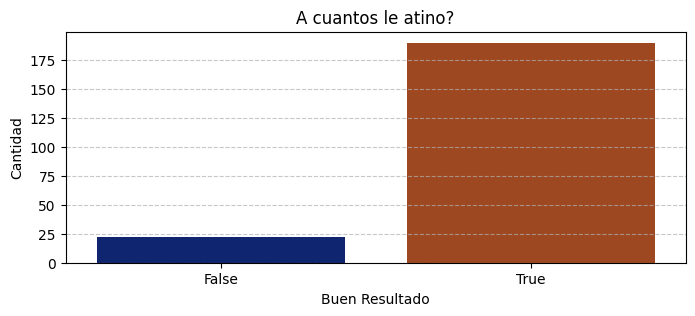

In [289]:
# ===================== veamos las proporcion le fue en las clasificaciones correctas ====================== #

# establecemos el lienzo
plt.figure(figsize = (8,3))

# configuramos la grafica de barras
sns.countplot(data = Comparati, x = 'Buen resultado', palette = 'dark')
plt.title('A cuantos le atino?')
plt.xlabel('Buen Resultado')
plt.ylabel('Cantidad')

# Configuramos el lienzo
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.show()


In [290]:
# Calculamos las proporcion de las buenas clasicaciones
clasic = Comparati['Buen resultado'].value_counts(normalize = True)
print(clasic)

Buen resultado
True     0.896226
False    0.103774
Name: proportion, dtype: float64


El modelo de clasificion es bueno; pero no saquemos conclusiones tan rapido, veamos como es la matriz de confusion...

In [291]:
# ===================== contruimos las matriz de confusion y sus terminos las representativos ======================

# importamos la funcion de la matriz de correlacion y una version mas adecuada para Y nos Booleanas
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# construimos la matriz de confusion
kung_fu = confusion_matrix(y_test, y_pred)

<Figure size 800x300 with 0 Axes>

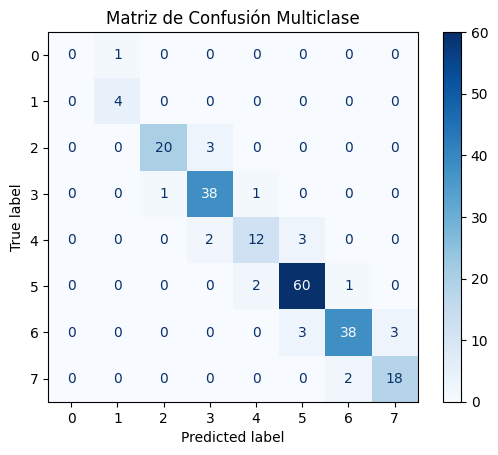

In [292]:
# ===================== para verlo mejor sera por un mapa de calor ======================

# Configuramos el tamaño del lienzo
plt.figure(figsize = (8,3))

# Configuramos las gráfica de calor; pero una matriz de confusion que es del tipo ordinal
disp = ConfusionMatrixDisplay(confusion_matrix = kung_fu)
disp.plot(cmap = 'Blues')

# Configuramos el mapa y el lienzo
plt.title("Matriz de Confusión Multiclase")
plt.show()

Como las V.A. Y no es booleana y de multiple clasificatorias; entonces el unico termino que podemos ver para las eficiencia del modelo sera **Accuary**

In [293]:
# ===================== terminos sobre la clasificacion ======================
from sklearn.metrics import accuracy_score

# presicion global
Eficiente = accuracy_score(y_test, y_pred)
print(f"El modelo tiene una eficiencia del: {round(Eficiente,3)}")

El modelo tiene una eficiencia del: 0.896


## $\color{green}{\text{Con Y = Gender}}$

In [294]:
# ===================== Partimos el database en train y test ====================== #

#importamos la sig, funcion:
from sklearn.model_selection import train_test_split

# Designamos que variable es quien:
X = adicc_1.drop('Gender', axis = 1)    # X sera las V.A.s independientes
Y = adicc_1['Gender']                   # Y sera las V.A. dependiente

# Vamos a entrenar el modelo con el 70% y con el 30% sera las parte del test
x_train_1, x_test_1, y_train_1, y_test_1 = train_test_split(X, Y, train_size = .70, test_size = .30, random_state = 42)

In [295]:
# ===================== Ajustamos el modelo ====================== #

# importamos el modelo de random forest por la paqueteria sklearn
from sklearn.ensemble import RandomForestClassifier

# Ajustamos los parametros del modelo
modelo = RandomForestClassifier(n_estimators = 37, random_state = 98)
modelo.fit(x_train_1, y_train_1)

RandomForestClassifier(n_estimators=37, random_state=98)

In [296]:
# ===================== ejecutamos el modelo con la parte de test ======================
y_pred_1 = modelo.predict(x_test_1)

Con este caso podemos ver los terminos que hemos visto en el modulo como es la matriz de confusion y la grafica ROC

In [297]:
# ===================== contruimos las matriz de confusion y sus terminos las representativos ======================

# importamos la funcion de la matriz de correlacion y una version mas adecuada para Y nos Booleanas
from sklearn.metrics import confusion_matrix

# construimos la matriz de confusion
kung_fu = confusion_matrix(y_test_1, y_pred_1)

<Figure size 300x300 with 0 Axes>

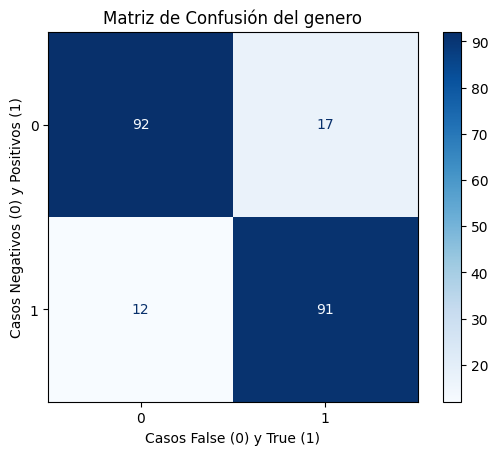

In [298]:
# ===================== para verlo mejor sera por un mapa de calor ======================

# Configuramos el tamaño del lienzo
plt.figure(figsize = (3,3))

# Configuramos las gráfica de calor; pero una matriz de confusion que es del tipo ordinal
disp = ConfusionMatrixDisplay(confusion_matrix = kung_fu)
disp.plot(cmap = 'Blues')

# Configuramos el mapa y el lienzo
plt.title("Matriz de Confusión del genero")
plt.xlabel("Casos False (0) y True (1)")
plt.ylabel("Casos Negativos (0) y Positivos (1)")
plt.show()

In [299]:
# ===================== terminos sobre la clasificacion ======================
from sklearn.metrics import accuracy_score, precision_score, recall_score

# presicion global
Eficiente = accuracy_score(y_test_1, y_pred_1)
print(f"El modelo tiene una eficiencia del: {round(Eficiente,3)}")

# presicion
Presicion = precision_score(y_test_1, y_pred_1)
print(f"El modelo tiene una presicion del: {round(Presicion,3)}")

# exactitud
Exactitud = recall_score(y_test_1, y_pred_1)
print(f"El modelo tiene una exactitud del: {round(Exactitud,3)}")

El modelo tiene una eficiencia del: 0.863
El modelo tiene una presicion del: 0.843
El modelo tiene una exactitud del: 0.883


In [300]:
# ===================== Las TPR, FPR Y AUC ======================

# importamos las funciones dedicadas para estos casos
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt

# Calcular los puntos de la curva ROC; con fpr = tasa de falsos positivos y tpr = tasa de verdaderos positivos
fpr, tpr, thresholds = roc_curve(y_test_1, y_pred_1)

# Calcular el AUC (area entre la recta y la curva ROC)
roc_auc = auc(fpr, tpr)

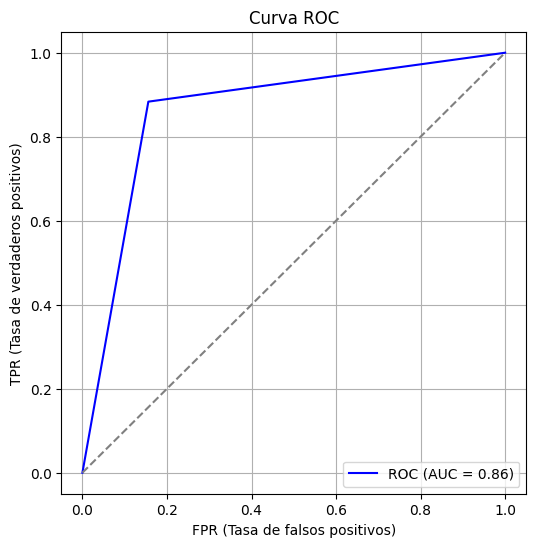

In [301]:
# ===================== Grafica ROC ======================

# establecemos el tamano del lienzo
plt.figure(figsize = (6, 6))

# configuramos los parametros de la grafica
plt.plot(fpr, tpr, label = f'ROC (AUC = {roc_auc:.2f})', color = 'blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')                        # RECTA PENDIENTE

# Vemos los elementos de la graficas
plt.xlabel('FPR (Tasa de falsos positivos)')
plt.ylabel('TPR (Tasa de verdaderos positivos)')
plt.title('Curva ROC')
plt.legend(loc = 'lower right')

# configuraciones del lienzo
plt.grid()
plt.show()

la grafica ROC no es al que esperabamos pero vamos a ver si se mejora con el modelo entrenado y toda la base de datos...

In [302]:
# ===================== ejecutamos el modelo con toda la base ======================
y_pred_2 = modelo.predict(X)

In [303]:
# ===================== Las TPR, FPR Y AUC ======================

# importamos las funciones dedicadas para estos casos
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt

# Calcular los puntos de la curva ROC; con fpr = tasa de falsos positivos y tpr = tasa de verdaderos positivos
fpr, tpr, thresholds = roc_curve(Y, y_pred_2)

# Calcular el AUC (area entre la recta y la curva ROC)
roc_auc = auc(fpr, tpr)

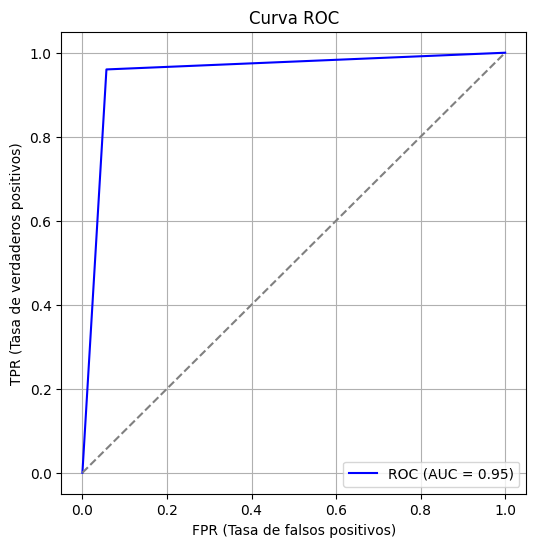

In [304]:
# ===================== Grafica ROC ======================

# establecemos el tamano del lienzo
plt.figure(figsize = (6, 6))

# configuramos los parametros de la grafica
plt.plot(fpr, tpr, label = f'ROC (AUC = {roc_auc:.2f})', color = 'blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')                        # RECTA PENDIENTE

# Vemos los elementos de la graficas
plt.xlabel('FPR (Tasa de falsos positivos)')
plt.ylabel('TPR (Tasa de verdaderos positivos)')
plt.title('Curva ROC')
plt.legend(loc = 'lower right')

# configuraciones del lienzo
plt.grid()
plt.show()

El cambio no mejora la curva; es casi la misma y por ello debemos de tener mas informacion que las V.A.s que contemplamos...

# $\color{blue}{\text{K-Means Clustering}}$

Para esta parte vamos detectra los grupos que se generan con la base de datos ya que nos ayudara a dar mejor perpectiva de la situacion...

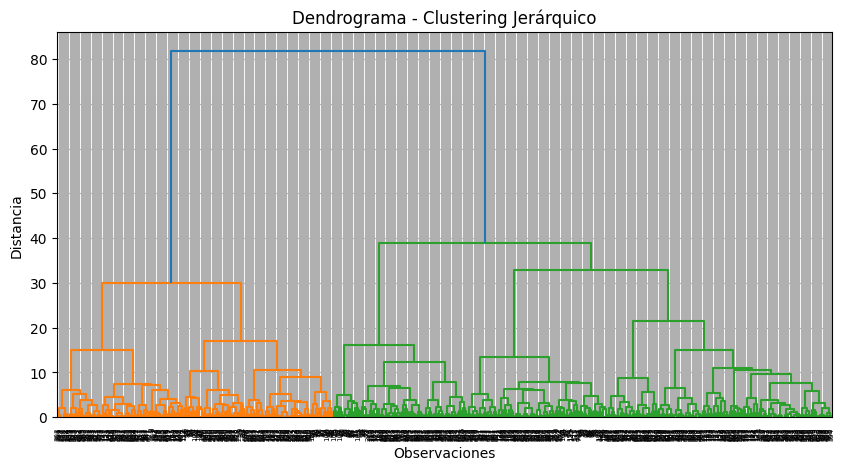

In [305]:
# ===================== Grafica de dedrongrama ======================

# Importamos 2 funcion: dedrogram que sera la grafica y la funcion linkage que nos ayuda en la jerarquias
from scipy.cluster.hierarchy import dendrogram, linkage

# Creamos las jeraraquia de agrupacion de los datos
Z = linkage(adicc_1, method = 'ward')

# establecemos el lienzo
plt.figure(figsize = (10, 5))

# Aplicamos la graficas
dendrogram(Z)

# configuramos los elementos de la grafica
plt.title("Dendrograma - Clustering Jerárquico")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")

# Mostrams las grafica
plt.grid()
plt.show()

La grafica Dendrograma consiste en la jerarquia de las distancia que tiene los registros, cada rama una la distancia que son similares desde los mas cercanos hasta una distancia estandar.

Si se traza una linea que corta la rama principal; la lineas que corte sera el numero de grupos mas apto para modelar...

In [306]:
# ===================== Aplicamos el modelo para determinar los 2 grupos que los clasifica ======================

# importamos solo el modelo
from sklearn.cluster import KMeans

# Implementamos el modelo con 2 grupos
kmeans = KMeans(n_clusters = 2, random_state = 42)
kmeans.fit(adicc_1)

# Agregamos la etiqueta de grupo a la database_original
Pro_gru = adicc.drop(273)
Pro_gru['Cluster'] = kmeans.labels_

# Visualizamos un poco la tabla
Pro_gru.head(12)

,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score,Cluster
Student_ID,,,,,,,,,,,,,
1,19,0,3,Bangladesh,5.2,Instagram,1,6.5,6,3,3,8,1
2,22,1,2,India,2.1,Twitter,0,7.5,8,2,0,3,0
3,20,0,3,USA,6.0,TikTok,1,5.0,5,1,4,9,1
4,18,1,1,UK,3.0,YouTube,0,7.0,7,2,1,4,0
5,21,1,2,Canada,4.5,Facebook,1,6.0,6,3,2,7,1
6,19,0,3,Australia,7.2,Instagram,1,4.5,4,1,5,9,1
7,23,1,2,Germany,1.5,LinkedIn,0,8.0,9,2,0,2,0
8,20,0,3,Brazil,5.8,Snapchat,1,6.0,6,3,2,8,1
9,18,1,1,Japan,4.0,TikTok,0,6.5,7,2,1,5,0
